In [1]:

import sys
import numpy as np
import sksurv

from sksurv.ensemble import RandomSurvivalForest

print("Python executable:", sys.executable)
print("NumPy:", np.__version__)
print("Scikit-survival:", sksurv.__version__)
print("All imports successful!")

Python executable: /opt/anaconda3/envs/metabric-survival/bin/python
NumPy: 2.5.3
Scikit-survival: 0.28.0
All imports successful!


In [3]:

import pandas as pd
from pathlib import Path

PROJECT_DIR = Path(
    "/Users/monicachaganti/Desktop/Ph.D/PROJECTS/brca_metabric"
)

PREPARED_DIR = PROJECT_DIR / "prepared_data"

X_train = pd.read_csv(
    PREPARED_DIR / "X_train_processed.csv"
)

X_test = pd.read_csv(
    PREPARED_DIR / "X_test_processed.csv"
)

y_train_df = pd.read_csv(
    PREPARED_DIR / "y_train.csv"
)

y_test_df = pd.read_csv(
    PREPARED_DIR / "y_test.csv"
)

print("Training features:", X_train.shape)
print("Test features:", X_test.shape)
print("Training outcomes:", y_train_df.shape)
print("Test outcomes:", y_test_df.shape)

Training features: (1583, 12)
Test features: (397, 12)
Training outcomes: (1583, 2)
Test outcomes: (397, 2)


In [5]:

from sksurv.util import Surv

y_train = Surv.from_dataframe(
    event="EVENT",
    time="OS_MONTHS",
    data=y_train_df.astype({"EVENT": bool})
)

y_test = Surv.from_dataframe(
    event="EVENT",
    time="OS_MONTHS",
    data=y_test_df.astype({"EVENT": bool})
)

print("Training outcomes:", y_train.shape)
print("Test outcomes:", y_test.shape)

print("Training events:", y_train["EVENT"].sum())
print("Test events:", y_test["EVENT"].sum())

print("Minimum training survival time:", y_train["OS_MONTHS"].min())
print("Minimum test survival time:", y_test["OS_MONTHS"].min())

print("Missing training features:", X_train.isna().sum().sum())
print("Missing test features:", X_test.isna().sum().sum())

Training outcomes: (1583,)
Test outcomes: (397,)
Training events: 915
Test events: 229
Minimum training survival time: 0.1
Minimum test survival time: 1.26666666666667
Missing training features: 0
Missing test features: 0


In [7]:

import numpy as np
from sklearn.model_selection import train_test_split

train_idx, val_idx = train_test_split(
    np.arange(len(X_train)),
    test_size=0.20,
    random_state=42,
    stratify=y_train["EVENT"]
)

X_fit = X_train.iloc[train_idx]
X_val = X_train.iloc[val_idx]

y_fit = y_train[train_idx]
y_val = y_train[val_idx]

print("Model training patients:", len(X_fit))
print("Validation patients:", len(X_val))
print("Model training events:", y_fit["EVENT"].sum())
print("Validation events:", y_val["EVENT"].sum())
print("Test patients reserved:", len(X_test))

Model training patients: 1266
Validation patients: 317
Model training events: 732
Validation events: 183
Test patients reserved: 397


In [9]:

from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored

rsf_initial = RandomSurvivalForest(
    n_estimators=200,
    min_samples_split=10,
    min_samples_leaf=15,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

rsf_initial.fit(X_fit, y_fit)

train_risk = rsf_initial.predict(X_fit)
val_risk = rsf_initial.predict(X_val)

train_cindex = concordance_index_censored(
    y_fit["EVENT"],
    y_fit["OS_MONTHS"],
    train_risk
)[0]

val_cindex = concordance_index_censored(
    y_val["EVENT"],
    y_val["OS_MONTHS"],
    val_risk
)[0]

print("RSF training C-index:", round(train_cindex, 4))
print("RSF validation C-index:", round(val_cindex, 4))

RSF training C-index: 0.7179
RSF validation C-index: 0.6729


In [11]:

from sklearn.model_selection import ParameterGrid

param_grid = {
    "min_samples_leaf": [5, 10, 15],
    "min_samples_split": [10, 20]
}

tuning_results = []

for params in ParameterGrid(param_grid):
    model = RandomSurvivalForest(
        n_estimators=200,
        min_samples_split=params["min_samples_split"],
        min_samples_leaf=params["min_samples_leaf"],
        max_features="sqrt",
        n_jobs=-1,
        random_state=42
    )

    model.fit(X_fit, y_fit)

    train_predictions = model.predict(X_fit)
    val_predictions = model.predict(X_val)

    train_score = concordance_index_censored(
        y_fit["EVENT"],
        y_fit["OS_MONTHS"],
        train_predictions
    )[0]

    val_score = concordance_index_censored(
        y_val["EVENT"],
        y_val["OS_MONTHS"],
        val_predictions
    )[0]

    tuning_results.append({
        "min_samples_leaf": params["min_samples_leaf"],
        "min_samples_split": params["min_samples_split"],
        "train_cindex": train_score,
        "val_cindex": val_score
    })

tuning_df = pd.DataFrame(tuning_results)

tuning_df = tuning_df.sort_values(
    "val_cindex",
    ascending=False
).reset_index(drop=True)

print(tuning_df.round(4).to_string(index=False))

 min_samples_leaf  min_samples_split  train_cindex  val_cindex
               10                 10        0.7319      0.6741
               10                 20        0.7319      0.6741
                5                 10        0.7679      0.6738
               15                 10        0.7179      0.6729
               15                 20        0.7179      0.6729
                5                 20        0.7507      0.6723


In [13]:

rsf_final = RandomSurvivalForest(
    n_estimators=200,
    min_samples_split=10,
    min_samples_leaf=10,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

rsf_final.fit(X_train, y_train)

print("Final RSF trained successfully")
print("Training patients:", len(X_train))
print("Number of trees:", rsf_final.n_estimators)
print("Minimum leaf size:", rsf_final.min_samples_leaf)

Final RSF trained successfully
Training patients: 1583
Number of trees: 200
Minimum leaf size: 10


In [15]:

rsf_train_risk = rsf_final.predict(X_train)
rsf_test_risk = rsf_final.predict(X_test)

rsf_train_cindex = concordance_index_censored(
    y_train["EVENT"],
    y_train["OS_MONTHS"],
    rsf_train_risk
)[0]

rsf_test_cindex = concordance_index_censored(
    y_test["EVENT"],
    y_test["OS_MONTHS"],
    rsf_test_risk
)[0]

print("Final RSF training C-index:", round(rsf_train_cindex, 4))
print("Final RSF test C-index:", round(rsf_test_cindex, 4))
print("Previous Cox test C-index:", 0.6548)

Final RSF training C-index: 0.7297
Final RSF test C-index: 0.6912
Previous Cox test C-index: 0.6548


In [17]:

time_5yr = 60.0

rsf_survival_functions = rsf_final.predict_survival_function(
    X_test
)

rsf_survival_5yr = np.array([
    survival_function(time_5yr)
    for survival_function in rsf_survival_functions
])

rsf_risk_5yr = 1 - rsf_survival_5yr

print("Number of test predictions:", len(rsf_survival_5yr))
print("Minimum five-year survival probability:", round(rsf_survival_5yr.min(), 4))
print("Maximum five-year survival probability:", round(rsf_survival_5yr.max(), 4))
print("Mean five-year survival probability:", round(rsf_survival_5yr.mean(), 4))
print("Missing predictions:", np.isnan(rsf_survival_5yr).sum())

Number of test predictions: 397
Minimum five-year survival probability: 0.3165
Maximum five-year survival probability: 0.9673
Mean five-year survival probability: 0.7739
Missing predictions: 0


In [21]:

from sksurv.metrics import brier_score

evaluation_times, rsf_brier_scores = brier_score(
    y_train,
    y_test,
    rsf_survival_5yr.reshape(-1, 1),
    times=np.array([60.0])
)

rsf_brier_5yr = rsf_brier_scores[0]

print("Evaluation time (months):", evaluation_times[0])
print("RSF five-year IPCW Brier score:", round(rsf_brier_5yr, 4))
print("Previous Cox five-year IPCW Brier score:", 0.1570)
print("Previous Kaplan-Meier baseline Brier score:", 0.1698)

Evaluation time (months): 60.0
RSF five-year IPCW Brier score: 0.1451
Previous Cox five-year IPCW Brier score: 0.157
Previous Kaplan-Meier baseline Brier score: 0.1698


In [23]:

from lifelines import KaplanMeierFitter

calibration_df = y_test_df.copy()

calibration_df["predicted_survival_5yr"] = rsf_survival_5yr

calibration_df["risk_group"] = pd.qcut(
    calibration_df["predicted_survival_5yr"],
    q=5,
    labels=False,
    duplicates="drop"
)

calibration_results = []

for group, group_df in calibration_df.groupby("risk_group"):
    kmf = KaplanMeierFitter()

    kmf.fit(
        durations=group_df["OS_MONTHS"],
        event_observed=group_df["EVENT"]
    )

    calibration_results.append({
        "group": int(group) + 1,
        "n_patients": len(group_df),
        "mean_predicted_survival": group_df["predicted_survival_5yr"].mean(),
        "observed_survival": kmf.predict(60.0)
    })

rsf_calibration = pd.DataFrame(calibration_results)

print(rsf_calibration.round(4).to_string(index=False))

 group  n_patients  mean_predicted_survival  observed_survival
     1          80                   0.5542             0.5640
     2          79                   0.7177             0.6425
     3          79                   0.8015             0.8318
     4          79                   0.8681             0.9487
     5          80                   0.9290             0.9375


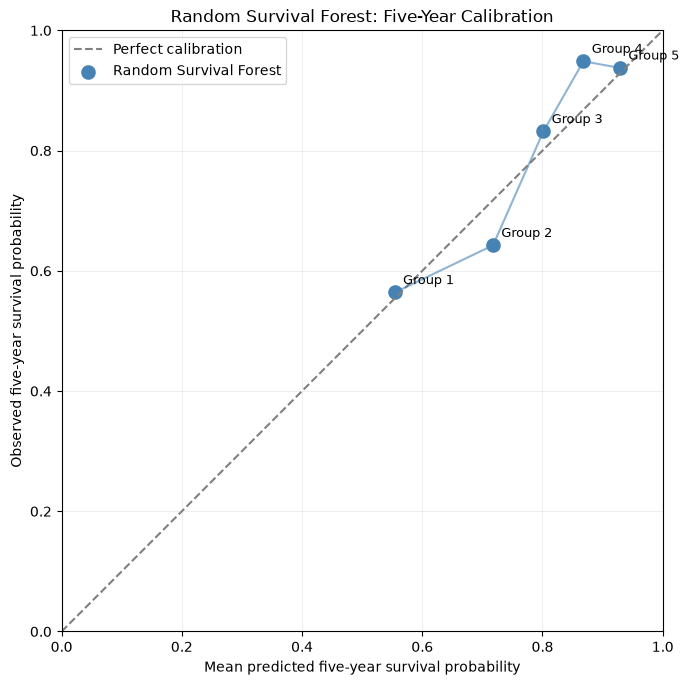

In [25]:

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 7))

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Perfect calibration"
)

ax.scatter(
    rsf_calibration["mean_predicted_survival"],
    rsf_calibration["observed_survival"],
    s=90,
    color="steelblue",
    label="Random Survival Forest"
)

ax.plot(
    rsf_calibration["mean_predicted_survival"],
    rsf_calibration["observed_survival"],
    color="steelblue",
    alpha=0.6
)

for _, row in rsf_calibration.iterrows():
    ax.annotate(
        f"Group {int(row['group'])}",
        (
            row["mean_predicted_survival"],
            row["observed_survival"]
        ),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9
    )

ax.set_xlabel("Mean predicted five-year survival probability")
ax.set_ylabel("Observed five-year survival probability")
ax.set_title("Random Survival Forest: Five-Year Calibration")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal", adjustable="box")
ax.grid(alpha=0.2)
ax.legend()

plt.tight_layout()
plt.show()

In [27]:

import joblib

RESULTS_DIR = PROJECT_DIR / "results"
MODELS_DIR = PROJECT_DIR / "models"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(
    rsf_final,
    MODELS_DIR / "random_survival_forest.joblib"
)

rsf_predictions = y_test_df.copy()

rsf_predictions["rsf_risk_score"] = rsf_test_risk
rsf_predictions["rsf_survival_5yr"] = rsf_survival_5yr
rsf_predictions["rsf_death_risk_5yr"] = rsf_risk_5yr

rsf_predictions.to_csv(
    RESULTS_DIR / "rsf_test_predictions.csv",
    index=False
)

rsf_calibration.to_csv(
    RESULTS_DIR / "rsf_calibration_5yr.csv",
    index=False
)

rsf_metrics = pd.DataFrame([{
    "model": "Random Survival Forest",
    "n_train": len(X_train),
    "n_test": len(X_test),
    "n_estimators": rsf_final.n_estimators,
    "min_samples_split": rsf_final.min_samples_split,
    "min_samples_leaf": rsf_final.min_samples_leaf,
    "max_features": rsf_final.max_features,
    "train_cindex": rsf_train_cindex,
    "test_cindex": rsf_test_cindex,
    "brier_5yr": rsf_brier_5yr
}])

rsf_metrics.to_csv(
    RESULTS_DIR / "rsf_metrics.csv",
    index=False
)

print("RSF model and results saved successfully")
print(rsf_metrics.round(4).to_string(index=False))

RSF model and results saved successfully
                 model  n_train  n_test  n_estimators  min_samples_split  min_samples_leaf max_features  train_cindex  test_cindex  brier_5yr
Random Survival Forest     1583     397           200                 10                10         sqrt        0.7297       0.6912     0.1451


In [29]:

fig.savefig(
    RESULTS_DIR / "rsf_calibration_5yr.png",
    dpi=300,
    bbox_inches="tight"
)

print("Calibration plot saved successfully")

Calibration plot saved successfully
